# Experiment 4: Hénon Strange Attractor + Ratio Validation

Reproduce Fig.4 (attractor) and Table 3 (ratio validation vs null baselines).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import subprocess, sys
sys.path.insert(0, '..')
from riemann_zeros import get_zeros
TRUE_ZEROS = get_zeros(100)

## 4a. Hénon Strange Attractor from SPICE

In [2]:
# Run autonomous Henon (a=1.4, b=0.3)
t_clk = 1e-6; n_steps = 5000; v_sat = 10.8
netlist = f"""* Henon attractor
Rxsrc v_xout txl_in 50\nTx1 txl_in 0 txl_out 0 Z0=50 TD={t_clk:.12e}
Rxload txl_out 0 50\nBxbuf v_x_del 0 V = 2*V(txl_out)
Rysrc v_yout tyl_in 50\nTy1 tyl_in 0 tyl_out 0 Z0=50 TD={t_clk:.12e}
Ryload tyl_out 0 50\nBybuf v_y_del 0 V = 2*V(tyl_out)
Bxmap v_xraw 0 V = 1.0 - 1.4*(1.004*V(v_x_del)*V(v_x_del)+0.05) + V(v_y_del)
Rxop v_xraw v_xfilt 160\nCxop v_xfilt 0 1n
Bxsat v_xout 0 V = {v_sat}*tanh(V(v_xfilt)/{v_sat})
Bymap v_yraw 0 V = 0.3*V(v_x_del)
Ryop v_yraw v_yfilt 160\nCyop v_yfilt 0 1n
Bysat v_yout 0 V = {v_sat}*tanh(V(v_yfilt)/{v_sat})
.ic V(v_xout)=0.1 V(v_yout)=0.1 V(v_xfilt)=0.1 V(v_yfilt)=0.1
+ V(txl_in)=0.05 V(txl_out)=0.05 V(tyl_in)=0.05 V(tyl_out)=0.05
.tran {t_clk/20:.12e} {n_steps*t_clk:.12e} uic
.control\nrun\nwrdata /tmp/att_out.txt v(v_xout) v(v_yout)\nquit\n.endc\n.end
"""
with open('/tmp/att.cir', 'w') as f: f.write(netlist)
subprocess.run(['ngspice', '-b', '/tmp/att.cir'], capture_output=True, text=True, timeout=60)
data = np.loadtxt('/tmp/att_out.txt')
t_arr = data[:, 0]; vx = data[:, 1]; vy = data[:, 3]

tx, ty = [], []
for i in range(10, n_steps):
    idx = np.searchsorted(t_arr, (i+0.5)*t_clk)
    if idx < len(vx): tx.append(float(vx[idx])); ty.append(float(vy[idx]))
tx, ty = np.array(tx), np.array(ty)
print(f'Attractor: {len(tx)} pts')

Attractor: 4990 pts


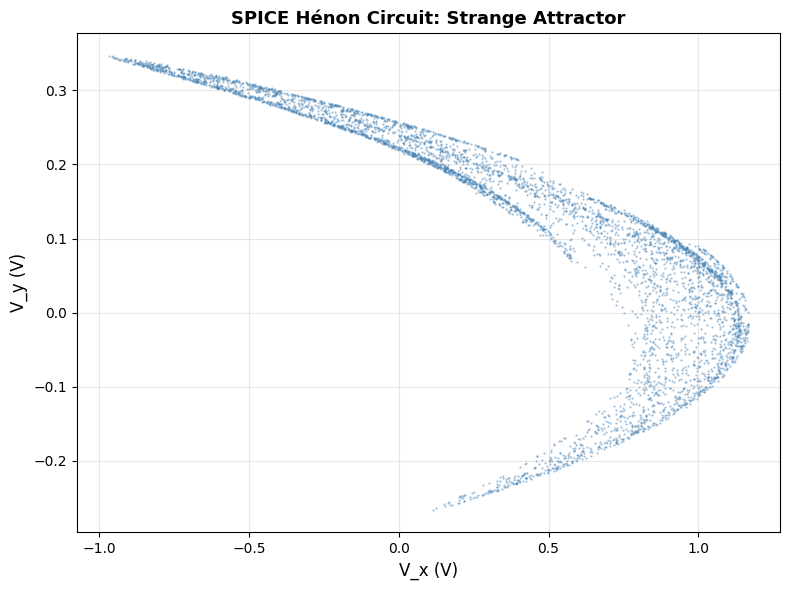

In [3]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(tx, ty, s=0.3, c='steelblue', alpha=0.5)
ax.set_xlabel('V_x (V)', fontsize=12)
ax.set_ylabel('V_y (V)', fontsize=12)
ax.set_title('SPICE Hénon Circuit: Strange Attractor', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig4a_attractor.png', dpi=200)
plt.show()

## 4b. Ratio Validation: Chaotic Eigenphases vs Null Baselines

In [4]:
from circuit_models import CircuitLogistic, MarkovBuilder, SpectralExtractor

# Chaotic eigenphases (ideal numerical, for baseline comparison)
model = CircuitLogistic(circuit=None)
traj = model.iterate(200000, seed=42)
P = MarkovBuilder.build_1d(traj, n_bins=1000, eps=0.005)
result = SpectralExtractor.extract(P, n_eigs=100, n_zeros=20, true_zeros=TRUE_ZEROS)
chaotic_phases = result['phases']

# Null baselines
n = min(20, len(chaotic_phases))
true_ratios = TRUE_ZEROS[:n] / TRUE_ZEROS[0]
chaotic_ratios = chaotic_phases[:n] / chaotic_phases[0]

null_results = {}
for name, phases in [
    ('Uniform', np.linspace(0.1, np.pi, 20)),
    ('Random', np.sort(np.random.RandomState(42).uniform(0.1, np.pi, 20))),
]:
    ratios = phases[:n] / phases[0]
    null_results[name] = float(np.mean(np.abs(ratios - true_ratios[:len(ratios)])))

chaotic_ratio_mae = float(np.mean(np.abs(chaotic_ratios - true_ratios)))

print(f'Ratio MAE comparison:')
print(f'  Chaotic eigenphases: {chaotic_ratio_mae:.4f}')
for name, mae in null_results.items():
    print(f'  {name}: {mae:.4f} ({mae/chaotic_ratio_mae:.1f}x worse)')

  MarkovBuilder.build_1d: n_bins=1000, eps=0.005000, nnz=19259, time=0.9s
Ratio MAE comparison:
  Chaotic eigenphases: 0.3064
  Uniform: 12.6727 (41.4x worse)
  Random: 5.6410 (18.4x worse)


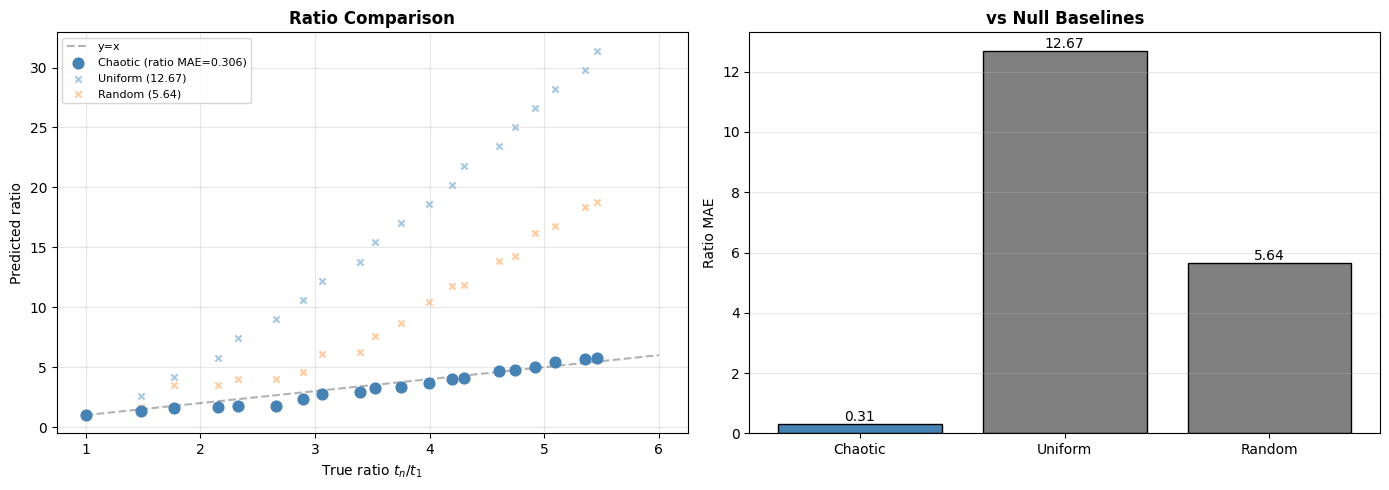

In [5]:
# Plot
# 如果你是在 Jupyter Notebook 中运行，建议在 Cell 的最前面加上这行魔法命令（如果你已经加过则不需要重复加）
%matplotlib inline
import matplotlib.pyplot as plt

# Plot ratio comparison

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot([1, 6], [1, 6], 'k--', alpha=0.3, label='y=x')
ax.scatter(true_ratios[:n], chaotic_ratios[:n], s=60, c='steelblue',
           label=f'Chaotic (ratio MAE={chaotic_ratio_mae:.3f})', zorder=5)
for name, phases in [('Uniform', np.linspace(0.1, np.pi, 20)),
                      ('Random', np.sort(np.random.RandomState(42).uniform(0.1, np.pi, 20)))]:
    ratios = phases[:n] / phases[0]
    ax.scatter(true_ratios[:len(ratios)], ratios[:len(true_ratios)],
              s=20, alpha=0.4, marker='x', label=f'{name} ({null_results[name]:.2f})')
ax.set_xlabel('True ratio $t_n/t_1$'); ax.set_ylabel('Predicted ratio')
ax.set_title('Ratio Comparison', fontweight='bold')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

ax = axes[1]
labels = ['Chaotic', 'Uniform', 'Random']
maes = [chaotic_ratio_mae] + list(null_results.values())
colors = ['steelblue', 'gray', 'gray']
bars = ax.bar(range(len(maes)), maes, color=colors, edgecolor='black')
for bar, mae in zip(bars, maes):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
            f'{mae:.2f}', ha='center', fontsize=10)
ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels)
ax.set_ylabel('Ratio MAE'); ax.set_title('vs Null Baselines', fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('fig4b_ratio_validation.png', dpi=200)
plt.show()